# 03. Mô hình Perceptron từ đầu (Perceptron from Scratch)

## 1. Cơ sở lý thuyết Perceptron
Perceptron là thuật toán phân loại tuyến tính nhị phân cổ điển (Frank Rosenblatt, 1957). Mô hình xác định nhãn dự đoán $\hat{y} \in \{0, 1\}$ dựa trên siêu phẳng:
$$z = w^T x + b$$
$$\hat{y} = \begin{cases} 1 & z \ge 0 \\ 0 & z < 0 \end{cases}$$

### Quy tắc cập nhật lỗi (Mistake-driven update):
Khi có lỗi phân loại $(y - \hat{y} \ne 0)$:
$$w \leftarrow w + \eta (y - \hat{y}) x$$
$$b \leftarrow b + \eta (y - \hat{y})$$

Hỗ trợ điều chuẩn L1 và L2 trên trọng số $w$ (không điều chuẩn bias $b$).

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.models.perceptron import PerceptronClassifier
from src.metrics import calculate_metrics, confusion_matrix

# 1. Đọc và tiền xử lý dữ liệu
df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=True)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Dữ liệu huấn luyện: {X_train_proc.shape}, Kiểm thử: {X_test_proc.shape}")

Dữ liệu huấn luyện: (238, 28), Kiểm thử: (59, 28)


## 2. Tìm kiếm siêu tham số (Hyperparameter Tuning)
Chúng ta thử nghiệm các tổ hợp tham số của `alpha` (mức độ điều chuẩn) và `penalty` (`None`, `'l2'`, `'l1'`).

In [2]:
alphas = [0.0001, 0.001, 0.01, 0.1]
penalties = [None, 'l2', 'l1']

best_score = -1.0
best_params = {}
best_model = None

for p in penalties:
    for a in alphas:
        clf = PerceptronClassifier(learning_rate=0.01, epochs=1000, penalty=p, alpha=a, random_state=42)
        clf.fit(X_train_proc, y_train)
        train_acc = np.mean(clf.predict(X_train_proc) == y_train)
        if train_acc > best_score:
            best_score = train_acc
            best_params = {'penalty': p, 'alpha': a}
            best_model = clf

print("Tập tham số tối ưu trên tập huấn luyện:", best_params)
print(f"Độ chính xác Train tốt nhất: {best_score:.4f}")

Tập tham số tối ưu trên tập huấn luyện: {'penalty': 'l1', 'alpha': 0.001}
Độ chính xác Train tốt nhất: 0.8487


## 3. Đánh giá trên tập kiểm thử (Test Evaluation)

Kết quả kiểm thử của Perceptron:
  Accuracy: 0.8305084745762712
  Precision: 0.84
  Recall: 0.7777777777777778
  F1_Score: 0.8076923076923077
  ROC_AUC: 0.888888888888889


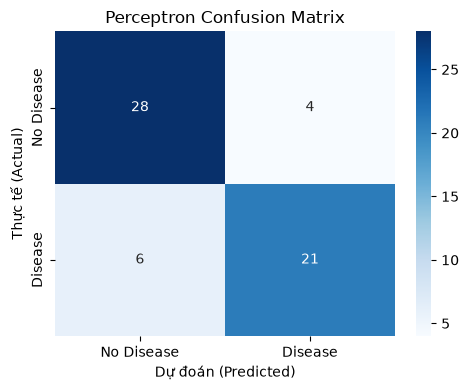

In [3]:
y_pred = best_model.predict(X_test_proc)
y_score = best_model.decision_function(X_test_proc)
metrics = calculate_metrics(y_test, y_pred, y_score)

print("Kết quả kiểm thử của Perceptron:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Perceptron Confusion Matrix')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.tight_layout()
plt.show()

## 4. Phân tích kết quả
- Perceptron phân tách dựa trên siêu phẳng đơn giản. Do dữ liệu bệnh tim có tính phi tuyến và nhiễu, Perceptron không thể hội tụ về nghiệm phân tách hoàn hảo.
- Tuy nhiên, mô hình vẫn đạt độ chính xác tương đối khá và cung cấp baseline tuyến tính khởi đầu.